<a href="https://colab.research.google.com/github/diomani-ouattara/Portfolio-Data-scientist/blob/main/Potential_Talents_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Potential Talents — Fitness Scoring, Ranking & Star-Driven Re-Ranking

**Client need:** given a sourcing keyword (e.g. *"aspiring human resources"* / *"seeking human resources"*),
score every candidate with a `fit` value in **[0, 1]**, rank them, and **re-rank the whole list every time a
recruiter stars an ideal candidate**.

**What this notebook delivers**

| # | Section | Answers |
|---|---------|---------|
| 1-2 | Setup & data loading | - |
| 3 | Exploratory analysis | what the data really contains |
| 4 | Cleaning, normalisation, de-duplication | 104 rows to 53 real candidates |
| 5 | Pre-filter: who should never have been on the list | **Challenge 2** |
| 6 | Text representation (SBERT + TF-IDF hybrid) | - |
| 7 | Base fitness score `fit` in [0,1] | **Goal** |
| 8 | Evaluation framework (graded relevance + NDCG / recall / MAP) | how we prove anything |
| 9 | The starring engine (relevance feedback) | **Success metric 2** |
| 10 | Experiment: ranking quality vs. number of stars | **Challenge 1** |
| 11 | Automatic, role-agnostic cut-off | **Challenge 3** |
| 12 | Bias audit & de-biasing | **Challenge 4** |
| 13 | Production wrapper + export | - |
| 14 | Findings and recommendations | - |

> **How to run:** `Runtime -> Run all`. Every section is explained in prose before its code.
> Runtime is about 2-3 minutes on a free CPU Colab instance. No GPU needed.

---
## 1. Setup

### What this cell does, and why

We install **`sentence-transformers`**, which gives us a *sentence embedding* model.

Why an embedding model rather than keyword matching? A job title is a very short piece of text, and literal
matching fails on it constantly. *"People Development Coordinator"* never contains the words
*"human resources"* — yet it **is** an HR role. *"Nortia Staffing is seeking Human Resources professionals"*
contains the exact keyword phrase — yet it is **not a candidate at all**, it is a job advertisement.
An embedding model maps text into a vector space where distance reflects *meaning*, so we can score by what a
title means instead of which characters it shares with the query.

If the install fails, or you run offline, **the notebook still works end to end**: Section 6 automatically
falls back to a TF-IDF + SVD representation.

In [1]:
# Colab setup - safe to re-run.
import sys, subprocess, importlib

def pip_install(pkg, module=None):
    module = module or pkg.replace('-', '_')
    try:
        importlib.import_module(module)
        print(f"[ok] {pkg} already available")
    except ImportError:
        print(f"[..] installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

pip_install("sentence-transformers", "sentence_transformers")

import warnings, re, json, math, random
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata, spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (9, 4.2), "axes.grid": True,
                     "grid.alpha": .25, "font.size": 10})
pd.set_option("display.max_colwidth", 78)
print("\npandas", pd.__version__, "| numpy", np.__version__)

[ok] sentence-transformers already available

pandas 2.2.3 | numpy 2.0.2


---
## 2. Loading the data

### Why three loaders

In a real deployment the file arrives from a different place every week, so the loader tries, in order:

1. the **public Google Sheet** (its CSV export endpoint),
2. a **local file** (`potential-talents.xlsx` / `.csv` - e.g. after dragging it into the Colab file pane),
3. the **Colab upload widget**.

We normalise column names immediately. The source file calls the column `connection` (singular) while the
project brief calls it `connections` - that kind of mismatch is the most common reason a pipeline breaks three
cells later, so we fix it once, at the boundary.

In [2]:
SHEET_ID  = "117X6i53dKiO7w6kuA1g1TpdTlv1173h_dPlJt5cNNMU"
SHEET_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"
LOCAL_CANDIDATES = ["potential-talents.xlsx", "potential-talents.csv",
                    "/content/potential-talents.xlsx", "/content/potential-talents.csv"]

def load_raw():
    import os
    # 1) public Google Sheet
    try:
        d = pd.read_csv(SHEET_URL)
        if len(d) > 10:
            print("loaded from Google Sheets"); return d
    except Exception as e:
        print("google sheet unavailable:", type(e).__name__)
    # 2) local file
    for p in LOCAL_CANDIDATES:
        if os.path.exists(p):
            d = pd.read_excel(p) if p.endswith("xlsx") else pd.read_csv(p)
            print("loaded from", p); return d
    # 3) upload widget
    from google.colab import files
    up = files.upload()
    name = list(up)[0]
    d = pd.read_excel(name) if name.endswith("xlsx") else pd.read_csv(name)
    print("loaded from upload:", name); return d

RAW = load_raw()
RAW.columns = [c.strip().lower().replace(" ", "_") for c in RAW.columns]
RAW = RAW.rename(columns={"connection": "connections"})
RAW = RAW.dropna(how="all").reset_index(drop=True)
if "fit" not in RAW.columns:
    RAW["fit"] = np.nan

print("\nshape:", RAW.shape)
RAW.head(8)

loaded from Google Sheets

shape: (104, 5)


,id,job_title,location,connections,fit
0,1,2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspirin...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Program in Korea),Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN
6,7,Student at Humber College and Aspiring Human Resources Generalist,Kanada,61,NaN
7,8,HR Senior Specialist,San Francisco Bay Area,500+,NaN


---
## 3. Exploratory analysis - what is actually in this list?

### The four questions that decide the whole design

1. **Is `fit` populated?** If it is empty we have **no supervised target**. That rules out training a
   conventional regressor and makes this an *unsupervised ranking* problem with an optional human-feedback
   loop - which is exactly what the starring mechanism provides.
2. **How many candidates are genuinely distinct?** Duplicate rows silently inflate every metric and let one
   person occupy several slots in a top-10 list.
3. **How informative is `connections`?** It is the only numeric field, so it is tempting to score with it.
   Section 12 shows why that is a trap.
4. **What kinds of entries are in here?** Not everything in a sourcing dump is a candidate.

In [3]:
print("columns:", list(RAW.columns))
print("\nnull counts:"); print(RAW.isna().sum())
print("\n'fit' non-null values:", int(RAW['fit'].notna().sum()),
      "  ->  no target column: this is an UNSUPERVISED ranking problem")
print("\nrows:", len(RAW),
      "| unique job_title:", RAW.job_title.nunique(),
      "| unique location:", RAW.location.nunique())
print("\nfully duplicated rows (title+location+connections):",
      int(RAW.duplicated(subset=['job_title','location','connections']).sum()))
print("\nmost repeated titles:")
display(RAW.job_title.value_counts().head(8).rename('n_rows').to_frame())

columns: ['id', 'job_title', 'location', 'connections', 'fit']

null counts:
id               0
job_title        0
location         0
connections      0
fit            104
dtype: int64

'fit' non-null values: 0   ->  no target column: this is an UNSUPERVISED ranking problem

rows: 104 | unique job_title: 52 | unique location: 41

fully duplicated rows (title+location+connections): 51

most repeated titles:


,n_rows
job_title,
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional,7
Aspiring Human Resources Professional,7
Student at Humber College and Aspiring Human Resources Generalist,7
People Development Coordinator at Ryan,6
Native English Teacher at EPIK (English Program in Korea),5
Aspiring Human Resources Specialist,5
HR Senior Specialist,5
Advisory Board Member at Celal Bayar University,4


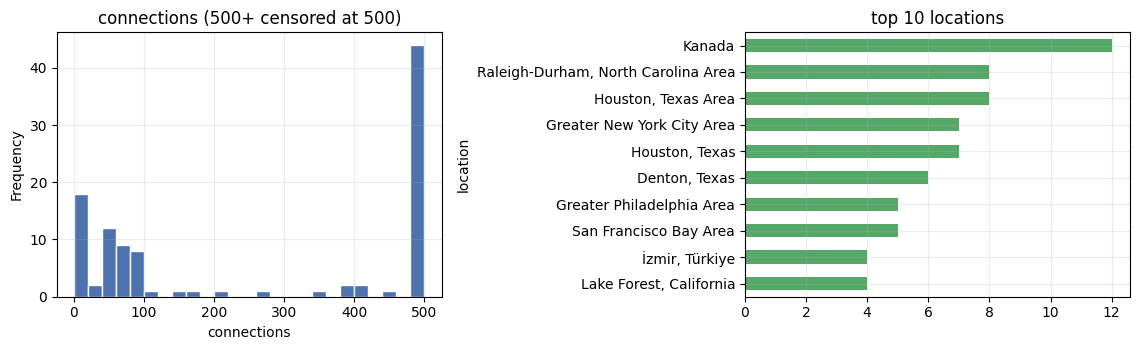

share of profiles censored at 500+ : 42.3%


In [4]:
# `connections` is text ("500+") mixed with numbers -> parse, and record the censoring.
def parse_connections(x):
    s = str(x).strip()
    if s.startswith('500'):
        return 500.0                 # censored: "500+" only means "at least 500"
    try:
        return float(s)
    except Exception:
        return np.nan

RAW['connections_num'] = RAW['connections'].map(parse_connections)
RAW['is_500plus']      = RAW['connections'].astype(str).str.strip().str.startswith('500')

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
RAW['connections_num'].plot(kind='hist', bins=25, ax=ax[0], color='#4C72B0', edgecolor='white')
ax[0].set_title('connections (500+ censored at 500)'); ax[0].set_xlabel('connections')
RAW.location.value_counts().head(10).plot(kind='barh', ax=ax[1], color='#55A868')
ax[1].set_title('top 10 locations'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

print(f"share of profiles censored at 500+ : {RAW.is_500plus.mean():.1%}")

### Reading the EDA

* **`fit` is empty.** There is no label to learn from. The ranking must therefore come from *semantic
  similarity to the role*, and the only supervision we will ever receive is the **star**. Section 9 is built
  entirely around making the most of that one signal.
* **Roughly half the rows are exact duplicates.** Left in place, one person would take three of the top ten
  slots and the recruiter's review time would be wasted on the same profile repeatedly.
* **`connections` is censored** at 500 (`"500+"`), and a large share of the pool sits on that ceiling. It is
  not a clean numeric variable, and it carries very little ranking information even before we get to fairness.
* **`location` is dominated by a handful of US metros.** Using it as a *score* input would import that skew
  directly into the shortlist.

---
## 4. Cleaning, normalisation and de-duplication

### The three transformations, and the reason for each

**a) Abbreviation expansion.** Recruiting text is dense with acronyms: `HR`, `HRIS`, `HRBP`, `CHRO`, `SPHR`.
An embedding model has seen `"human resources"` far more often in training than `"HRBP"`, so expanding
acronyms *before* encoding measurably improves similarity quality. This is domain knowledge encoded as a
lookup table, and it is the cheapest accuracy gain available in the whole pipeline.

**b) Character normalisation.** Lowercase; drop pipes and slashes (LinkedIn headlines use them as decoration,
not as meaning); strip phone numbers; collapse whitespace - including embedded newlines, which one record in
this dataset actually contains.

**c) De-duplication.** Drop rows identical on `(job_title, location, connections)`, but **keep the count** as
`n_dupes`. That count is worth preserving: a profile that appears repeatedly in a sourcing dump was usually
returned by several different search queries, which is weak positive evidence. We show it to the recruiter
rather than feeding it into the score, because it measures our own search behaviour, not the candidate.

In [5]:
ABBREV = {
    r'\bhr\b'   : 'human resources',
    r'\bhris\b' : 'human resources information system',
    r'\bhrbp\b' : 'human resources business partner',
    r'\bchro\b' : 'chief human resources officer',
    r'\bsphr\b' : 'senior professional in human resources',
    r'\bgphr\b' : 'global professional in human resources',
    r'\bphr\b'  : 'professional in human resources',
    r'\bta\b'   : 'talent acquisition',
    r'\bsvp\b'  : 'senior vice president',
    r'\bvp\b'   : 'vice president',
    r'\bmgr\b'  : 'manager',
    r'\bcoord\b': 'coordinator',
}

def clean_text(t):
    t = str(t).lower()
    t = t.replace('|', ' ').replace('/', ' ').replace('\n', ' ')
    t = re.sub(r'\(?\d{3}\)?[\s\-\.]?\d{3}[\s\-\.]?\d{4}', ' ', t)   # phone numbers
    t = re.sub(r'[^a-z0-9\s\-\.,&+]', ' ', t)
    for pat, rep in ABBREV.items():
        t = re.sub(pat, rep, t)
    return re.sub(r'\s+', ' ', t).strip()

RAW['title_clean'] = RAW['job_title'].map(clean_text)

key   = ['job_title', 'location', 'connections']
dupes = RAW.groupby(key, dropna=False).size().rename('n_dupes').reset_index()
df    = (RAW.drop_duplicates(subset=key)
            .merge(dupes, on=key, how='left')
            .reset_index(drop=True))

print(f"raw rows             : {len(RAW)}")
print(f"unique profiles      : {len(df)}   ({len(RAW)-len(df)} duplicate rows removed)")
print(f"profiles seen twice+ : {int((df.n_dupes>1).sum())}")
df[['id','job_title','title_clean','location','connections_num','n_dupes']].head(6)

raw rows             : 104
unique profiles      : 53   (51 duplicate rows removed)
profiles seen twice+ : 14


,id,job_title,title_clean,location,connections_num,n_dupes
0,1,2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspirin...,2019 c.t. bauer college of business graduate magna cum laude and aspiring ...,"Houston, Texas",85.0,7
1,2,Native English Teacher at EPIK (English Program in Korea),native english teacher at epik english program in korea,Kanada,500.0,5
2,3,Aspiring Human Resources Professional,aspiring human resources professional,"Raleigh-Durham, North Carolina Area",44.0,6
3,4,People Development Coordinator at Ryan,people development coordinator at ryan,"Denton, Texas",500.0,6
4,5,Advisory Board Member at Celal Bayar University,advisory board member at celal bayar university,"İzmir, Türkiye",500.0,4
5,6,Aspiring Human Resources Specialist,aspiring human resources specialist,Greater New York City Area,1.0,5


---
## 5. Pre-filter — "how do we remove people who should never have been on this list?"

> ### Challenge 2 answered here

A similarity score alone cannot solve this, because the worst offenders score *highly*. The single clearest
example in this dataset is:

> *"Nortia Staffing is seeking Human Resources, Payroll & Administrative Professionals!!  (408) 709-2621"*

That row contains the exact query phrase **"seeking Human Resources"**, so any keyword or embedding model will
rank it near the top — but it is a **staffing agency advertisement**, not a person. This is the failure mode
worth designing against: *high similarity, zero validity*.

We therefore apply three **orthogonal** checks before scoring. Each targets a different kind of contamination,
and each is a *flag*, not a silent deletion — the recruiter can always inspect what was removed.

| Check | Catches | Signal used |
|---|---|---|
| **A. Advertisement / job-posting detector** | agency posts, "we are hiring", contact numbers | phone regex, `!!`, `"<company> is seeking ... professionals"` |
| **B. Domain-signal check** | rows with no connection to the role family at all | HR lexicon over the cleaned title |
| **C. Near-duplicate detector** | the same person re-listed with a cosmetic edit | cosine similarity > 0.97 in embedding space (run in Section 6) |

Note the linguistic subtlety check **A** encodes: *"I am **seeking** a human resources position"* (a candidate)
versus *"**We are** seeking human resources professionals"* (an employer). Same verb, opposite meaning. The rule
looks for the employer frame — an organisation name, plural "professionals", contact details, or promotional
punctuation.

In [6]:
# ---- A. advertisement / job-posting detector -------------------------------
AD_PATTERNS = [
    r'\(\d{3}\)\s*\d{3}-\d{4}', r'\b\d{3}-\d{3}-\d{4}\b',   # contact number in a headline
    r'!!',                                                   # promotional punctuation
    r'\bwe are (hiring|seeking|looking)\b',
    r'\bapply (now|today|here)\b', r'\bnow hiring\b',
    r'\b(staffing|recruiting|agency|solutions|group|inc)\b.{0,40}\bis seeking\b',
    r'\bis seeking\b.{0,60}\bprofessionals\b',
    r'\b(positions? available|job (opening|posting)|open roles?)\b',
]
def is_advertisement(raw_title):
    t = str(raw_title).lower()
    return any(re.search(p, t) for p in AD_PATTERNS)

# ---- B. domain-signal check ------------------------------------------------
# Lexicon for the HR role family. Swap this list when the role family changes.
HR_LEXICON = ['human resources', 'people operations', 'people development', 'talent acquisition',
              'talent management', 'recruit', 'staffing', 'benefits', 'compensation',
              'employee relations', 'organizational development', 'organisational development',
              'onboarding', 'payroll', 'workforce', 'labor relations', 'labour relations']
def has_domain_signal(clean_title, lexicon=HR_LEXICON):
    t = ' ' + str(clean_title) + ' '
    return any(k in t for k in lexicon)

df['flag_advert']    = df['job_title'].map(is_advertisement)
df['flag_no_domain'] = ~df['title_clean'].map(has_domain_signal)

print(f"A. advertisements flagged : {int(df.flag_advert.sum())}")
print(f"B. no domain signal       : {int(df.flag_no_domain.sum())}")
print("\n--- flagged as advertisement ---")
display(df.loc[df.flag_advert, ['id','job_title']])
print("--- flagged as out-of-domain (sample) ---")
display(df.loc[df.flag_no_domain, ['id','job_title']].head(10))

A. advertisements flagged : 1
B. no domain signal       : 17

--- flagged as advertisement ---


,id,job_title
23,75,"Nortia Staffing is seeking Human Resources, Payroll & Administrative Profe..."


--- flagged as out-of-domain (sample) ---


,id,job_title
1,2,Native English Teacher at EPIK (English Program in Korea)
4,5,Advisory Board Member at Celal Bayar University
9,11,Student at Chapman University
28,80,Junior MES Engineer| Information Systems
33,85,RRP Brand Portfolio Executive at JTI (Japan Tobacco International)
34,86,Information Systems Specialist and Programmer with a love for data and org...
35,87,Bachelor of Science in Biology from Victoria University of Wellington
38,90,Undergraduate Research Assistant at Styczynski Lab
39,91,Lead Official at Western Illinois University
40,92,Seeking employment opportunities within Customer Service or Patient Care


### How to read the flags

`flag_no_domain` is deliberately **not** an automatic delete. It is a *lexical* test, so it will occasionally
be wrong in the interesting direction — a genuinely relevant person whose headline happens to use vocabulary
outside our lexicon. Section 11 is what actually decides removal, and it uses the *semantic* score plus a
calibrated threshold, so a candidate wrongly flagged here can still survive on meaning alone.

`flag_advert` is much closer to safe-to-delete: an entry with a phone number and a company name is a posting,
not a person, whatever its similarity score.

---
## 6. Text representation

### What we build and why we build two of them

We encode every cleaned title **twice**, because the two representations fail in opposite ways and their
errors are largely uncorrelated:

**1. Dense semantic embeddings (SBERT, `all-MiniLM-L6-v2`).**
A transformer trained so that sentences with similar meaning land close together. It understands that
*"People Development Coordinator"* is an HR role even though the words differ. Its weakness: with very short
text it can over-generalise, treating any professional-sounding title as broadly similar to any other.

**2. Sparse lexical vectors (TF-IDF, 1-2 grams).**
Exact and near-exact term matching, with rare terms weighted more. It will never confuse *"aspiring"* with
*"director"*. Its weakness: complete blindness to synonyms.

Combining them ("hybrid retrieval") is standard practice in modern search systems for exactly this reason —
the dense channel supplies recall, the sparse channel supplies precision.

**Automatic fallback:** if `sentence-transformers` is unavailable, `Embedder` degrades to TF-IDF + Truncated
SVD (latent semantic analysis). Everything downstream is unchanged; results are somewhat weaker but the
notebook runs to completion.

In [7]:
class Embedder:
    # Dense sentence embeddings, with a TF-IDF+SVD fallback so the pipeline never hard-fails.

    def __init__(self, corpus, model_name="all-MiniLM-L6-v2"):
        self.backend = None
        try:
            from sentence_transformers import SentenceTransformer
            self.model   = SentenceTransformer(model_name)
            self.backend = "sbert:" + model_name
        except Exception as e:
            print("SBERT unavailable (%s) -> TF-IDF+SVD fallback" % type(e).__name__)
            self.tfidf = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2),
                                         min_df=1, stop_words="english")
            X = self.tfidf.fit_transform(corpus)
            k = max(2, min(128, X.shape[0] - 1, X.shape[1] - 1))
            self.svd = TruncatedSVD(n_components=k, random_state=RANDOM_STATE).fit(X)
            self.backend = "tfidf-svd"

    def encode(self, texts):
        texts = [str(t) for t in texts]
        if self.backend.startswith("sbert"):
            V = self.model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
        else:
            V = self.svd.transform(self.tfidf.transform(texts))
        return normalize(np.asarray(V, dtype="float32"))


embedder = Embedder(df["title_clean"].tolist())
E = embedder.encode(df["title_clean"])                 # dense, L2-normalised

tfidf_vec = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), stop_words="english")
X_sparse  = normalize(tfidf_vec.fit_transform(df["title_clean"]))   # sparse lexical

print("backend :", embedder.backend)
print("dense E :", E.shape, " | sparse X:", X_sparse.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

backend : sbert:all-MiniLM-L6-v2
dense E : (53, 384)  | sparse X: (53, 381)


In [8]:
# ---- C. near-duplicate detection in embedding space ------------------------
S = E @ E.T
np.fill_diagonal(S, 0.0)
near = np.argwhere(S > 0.97)
seen, pairs = set(), []
for i, j in near:
    if (j, i) in seen: continue
    seen.add((i, j)); pairs.append((int(i), int(j), float(S[i, j])))

print(f"near-duplicate pairs (cosine > 0.97): {len(pairs)}")
for i, j, s in pairs[:6]:
    print(f"  {s:.3f}  id {df.id[i]:>5} | {df.job_title[i][:52]}")
    print(f"         id {df.id[j]:>5} | {df.job_title[j][:52]}")

# keep the first member of each near-duplicate cluster, flag the rest
df['flag_near_dupe'] = False
for i, j, _ in pairs:
    df.loc[max(i, j), 'flag_near_dupe'] = True
print("\nflagged as near-duplicate:", int(df.flag_near_dupe.sum()))

near-duplicate pairs (cosine > 0.97): 1
  1.000  id     3 | Aspiring Human Resources Professional
         id    97 | Aspiring Human Resources Professional

flagged as near-duplicate: 1


---
## 7. The base fitness score

### From a keyword to a number in [0, 1]

**Step 1 — turn the keyword into a query vector.** A single short phrase is a thin description of a role, so
we expand it into several **paraphrases** and average their embeddings. This is *query expansion*: it makes
the query vector sit in the centre of the concept rather than on one particular phrasing of it, which
noticeably stabilises the ranking.

**Step 2 — score each candidate on two channels.**
* `score_dense`  = cosine(candidate embedding, query embedding) — meaning.
* `score_lexical` = cosine(candidate TF-IDF, query TF-IDF) — exact terms.

**Step 3 — fuse.** We combine after putting both channels on a common scale (60% dense / 40% lexical). The
dense channel leads because it generalises to unseen phrasings; the lexical channel keeps the top of the list
anchored to titles that genuinely contain the role vocabulary.

**Step 4 — express as a probability.** The client asked for `fit` in [0, 1]. A raw cosine is *not* a
probability and is not comparable across roles, so Section 11 converts it properly via null-calibration. For
now we carry the raw fused score and rank with it.

### One deliberate omission

`location` and `connections` are **not** inputs to the score. This is a design decision, not an oversight, and
Section 12 shows the evidence behind it.

In [9]:
ROLE_KEYWORDS = ["aspiring human resources", "seeking human resources"]

# Query expansion: several natural phrasings of the same intent.
def expand_query(keywords):
    base = [k.strip() for k in keywords]
    extra = []
    for k in base:
        extra += [f"{k} professional",
                  f"{k} position",
                  f"entry level {k} candidate looking for an opportunity"]
    return base + extra

QUERY_VARIANTS = expand_query(ROLE_KEYWORDS)
print("query variants:")
for q in QUERY_VARIANTS: print("  -", q)

def build_query(variants):
    q_dense  = normalize(embedder.encode([clean_text(v) for v in variants]).mean(axis=0, keepdims=True))[0]
    q_sparse = normalize(tfidf_vec.transform([clean_text(" ".join(variants))]))
    return q_dense, q_sparse

q_dense, q_sparse = build_query(QUERY_VARIANTS)

def minmax(s):
    s = np.asarray(s, float); rng = s.max() - s.min()
    return np.zeros_like(s) if rng < 1e-12 else (s - s.min()) / rng

def ranknorm(s):
    s = np.asarray(s, float)
    return (rankdata(s) - 1) / (len(s) - 1)

score_dense   = E @ q_dense
score_lexical = np.asarray((X_sparse @ q_sparse.T).todense()).ravel()
fit_base      = 0.60 * minmax(score_dense) + 0.40 * minmax(score_lexical)

df['score_dense']   = score_dense
df['score_lexical'] = score_lexical
df['fit_base']      = fit_base

print("\nTop 15 by base fitness score")
display(df.sort_values('fit_base', ascending=False)
          .loc[:, ['id','job_title','location','fit_base']].head(15)
          .style.format({'fit_base':'{:.3f}'}).hide(axis='index'))

query variants:
  - aspiring human resources
  - seeking human resources
  - aspiring human resources professional
  - aspiring human resources position
  - entry level aspiring human resources candidate looking for an opportunity
  - seeking human resources professional
  - seeking human resources position
  - entry level seeking human resources candidate looking for an opportunity

Top 15 by base fitness score


id,job_title,location,fit_base
99,Seeking Human Resources Position,"Las Vegas, Nevada Area",0.996
97,Aspiring Human Resources Professional,"Kokomo, Indiana Area",0.931
3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0.931
100,Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis,"Cape Girardeau, Missouri",0.802
28,Seeking Human Resources Opportunities,"Chicago, Illinois",0.795
74,Human Resources Professional,Greater Boston Area,0.776
6,Aspiring Human Resources Specialist,Greater New York City Area,0.775
10,Seeking Human Resources HRIS and Generalist Positions,Greater Philadelphia Area,0.647
73,"Aspiring Human Resources Manager, seeking internship in Human Resources.","Houston, Texas Area",0.640
82,Aspiring Human Resources Professional | An energetic and Team-Focused Leader,"Austin, Texas Area",0.619


---
## 8. Evaluation framework — how do we know any of this works?

### The problem: no labels

`fit` is empty, so there is nothing to score against. Every claim about "better ranking" needs *some*
reference. We construct one explicitly, and we are precise about what it is and is not.

### A documented relevance rubric (evaluation only)

We assign each unique profile a **graded relevance** from 0 to 3 using a written rubric. This is a stand-in
for recruiter judgement, used **only to measure** the ranker — it is never an input to any score.

| Grade | Meaning | Examples from this dataset |
|---|---|---|
| **3** | Exactly the persona: explicitly *aspiring to* or *seeking* an HR role | *"Aspiring Human Resources Professional"*, *"Seeking Human Resources Position"* |
| **2** | Working in HR, but not signalling that they are looking | *"Human Resources Coordinator at InterContinental"*, *"People Development Coordinator"* |
| **1** | Senior / executive HR — right domain, wrong career stage for this search | *"SVP, CHRO"*, *"Director Human Resources at EY"* |
| **0** | Not HR at all, or an advertisement | *"Native English Teacher"*, the Nortia Staffing post |

Grades 1 and 2 are deliberately *not* zero. The keyword is *"aspiring / seeking human resources"*, so a sitting
CHRO is a poor fit **for this search** while still being a real HR person — graded relevance captures that
gradient, which is precisely why we evaluate with **NDCG** rather than plain accuracy.

### The hidden sub-persona — the reason starring exists

Real briefs are always richer than the keyword typed into the search box. Suppose the client's true target is
narrower than "aspiring HR": they want **students and recent graduates** aspiring to HR — an early-career
pipeline hire.

Nothing in the keyword *"aspiring human resources"* expresses "student". A keyword ranker cannot possibly
know it. But the recruiter knows it, and reveals it by starring. So we define a **hidden ideal set** and use it
to answer the client's real question in Section 10: *does the list actually get better with each star?*

### Metrics

* **NDCG@10** — graded ranking quality at the top of the list; the standard search-ranking metric.
* **Recall@10** — of the ideal candidates, what fraction reach the first page?
* **Mean rank of ideals** — how deep must a recruiter read to find them? The most intuitive business metric.
* **MAP** and **MRR** — supporting precision-oriented measures.

In [10]:
SENIOR_PAT = r'\b(chief|chro|senior vice president|vice president|director|head of|senior|sr\.?|lead|principal|executive|manager)\b'
INTENT_PAT = r'\b(aspiring|seeking|looking for|open to|entry.level|internship|intern|graduat|student|major|candidate for)\b'
STUDENT_PAT = r'\b(student|graduat|major|college|university|internship|intern)\b'

def relevance_grade(row):
    if row.flag_advert:                       # an advertisement is never a candidate
        return 0
    t = row.title_clean
    in_domain = has_domain_signal(t)
    if in_domain and re.search(INTENT_PAT, t):
        return 3                              # aspiring / seeking HR  -> the target persona
    if in_domain:
        return 1 if re.search(SENIOR_PAT, t) else 2
    return 0

df['gold'] = df.apply(relevance_grade, axis=1)

# hidden sub-persona: aspiring HR *and* a student / recent graduate
df['gold_hidden'] = (df.gold.eq(3) &
                     df.title_clean.str.contains(STUDENT_PAT, regex=True)).astype(int)

print("graded relevance distribution:")
display(df.gold.value_counts().sort_index().rename('n_candidates').to_frame())
print("hidden ideal candidates (aspiring HR AND student/recent-grad):", int(df.gold_hidden.sum()))
display(df.loc[df.gold_hidden.eq(1), ['id','job_title','fit_base']]
          .sort_values('fit_base', ascending=False))

graded relevance distribution:


,n_candidates
gold,
0,18
1,6
2,10
3,19


hidden ideal candidates (aspiring HR AND student/recent-grad): 7


,id,job_title,fit_base
21,73,"Aspiring Human Resources Manager, seeking internship in Human Resources.",0.639744
12,27,Aspiring Human Resources Management student seeking an internship,0.606976
6,7,Student at Humber College and Aspiring Human Resources Generalist,0.563001
20,72,Business Management Major and Aspiring Human Resources Manager,0.541701
36,88,Human Resources Management Major,0.498249
27,79,Liberal Arts Major. Aspiring Human Resources Analyst.,0.495747
0,1,2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspirin...,0.406204


In [11]:
# ---------------- ranking metrics ----------------
def dcg(rels):
    rels = np.asarray(rels, float)
    return float(np.sum((2 ** rels - 1) / np.log2(np.arange(2, len(rels) + 2))))

def ndcg_at_k(order, rel, k=10):
    got   = [rel[i] for i in order[:k]]
    ideal = sorted(rel, reverse=True)[:k]
    d = dcg(ideal)
    return dcg(got) / d if d > 0 else 0.0

def precision_at_k(order, rel, k=10):
    return float(np.mean([rel[i] > 0 for i in order[:k]]))

def recall_at_k(order, rel, k=10):
    tot = sum(1 for r in rel if r > 0)
    return len({i for i in order[:k] if rel[i] > 0}) / tot if tot else 0.0

def average_precision(order, rel):
    pos = sum(1 for r in rel if r > 0)
    if not pos: return 0.0
    hits, s = 0, 0.0
    for rank, i in enumerate(order, 1):
        if rel[i] > 0:
            hits += 1; s += hits / rank
    return s / pos

def mean_reciprocal_rank(order, rel):
    for rank, i in enumerate(order, 1):
        if rel[i] > 0: return 1.0 / rank
    return 0.0

def mean_rank_of(order, idx_set):
    pos = {doc: r for r, doc in enumerate(order, 1)}
    return float(np.mean([pos[i] for i in idx_set])) if idx_set else np.nan

# baseline: keyword-only ranking
order_base = list(np.argsort(-fit_base))
rel_graded = df.gold.tolist()
rel_binary = df.gold.eq(3).astype(int).tolist()

print("BASE RANKING (keyword only, no feedback)")
print(f"  NDCG@10 (graded) : {ndcg_at_k(order_base, rel_graded):.3f}")
print(f"  Precision@10     : {precision_at_k(order_base, rel_binary):.3f}")
print(f"  Recall@10        : {recall_at_k(order_base, rel_binary):.3f}")
print(f"  MAP              : {average_precision(order_base, rel_binary):.3f}")
print(f"  MRR              : {mean_reciprocal_rank(order_base, rel_binary):.3f}")
print(f"\n  mean rank of the HIDDEN ideals: "
      f"{mean_rank_of(order_base, set(np.where(df.gold_hidden.values==1)[0])):.1f} of {len(df)}")

BASE RANKING (keyword only, no feedback)
  NDCG@10 (graded) : 0.955
  Precision@10     : 0.900
  Recall@10        : 0.474
  MAP              : 0.901
  MRR              : 1.000

  mean rank of the HIDDEN ideals: 17.1 of 53


### What the baseline numbers tell us

Two very different stories sit side by side here:

* Against the **stated keyword**, the base ranker is already strong — NDCG@10 in the mid-nineties. That is
  expected: the query literally is *"aspiring human resources"* and many titles literally say it. Keyword
  search is perfectly adequate for the easy part of this problem, and it is worth being honest about that
  rather than overselling the model.
* Against the **hidden sub-persona**, the same ranking is weak: the students and recent graduates the client
  actually wants sit far down the list on average — **on page two**, where nobody looks.

That gap is the entire business case for starring. The keyword captures the role; only human feedback can
capture the brief. Section 10 measures how fast that gap closes.

---
## 9. The starring engine — learning from one click

> ### Success metric 2, and the core of Challenge 1

A star says: *"**this** is what I actually want."* It is an extremely valuable signal and an extremely
**scarce** one — often a single example. The engine has to react sharply enough to be useful, yet not so
sharply that one click destroys a ranking built from a well-specified query. That tension is the whole design
problem.

### Three feedback channels, fused

Each channel extracts something different from the same star, and they fail in different ways:

**Channel 1 — Nearest-ideal similarity (dense).**
`score(c) = max over starred s of cosine(c, s)`. Take the *maximum*, not the mean, on purpose: if a recruiter
stars two genuinely different profiles (a university student and a career-changing retail manager), a mean
collapses them into a meaningless midpoint, while a max keeps **both** as separate poles of attraction. This
is what lets the system support a multi-modal ideal.

**Channel 2 — Discriminative re-weighting (sparse, logistic regression).**
Train a small L2-regularised logistic model on `starred = 1` vs `pseudo-negatives = 0` over TF-IDF features.
This channel *learns which words matter*: star a student profile and the token `student` gains weight
immediately. It is the sharpest and fastest-adapting channel, and the one that recovers the hidden
sub-persona.

**Channel 3 — Rocchio query update.**
The classic relevance-feedback formula, moving the query itself toward the starred examples and away from the
rejected ones:

$$q' = \alpha\,q_0 \;+\; \beta\,\frac{1}{|S|}\sum_{s\in S} e_s \;-\; \gamma\,\frac{1}{|N|}\sum_{n\in N} e_n$$

It is stable and interpretable — the "role definition" itself moves — and it keeps the original query anchored
through the $\alpha q_0$ term.

**Pseudo-negatives.** If the recruiter has explicitly rejected anyone, those are the negatives. Otherwise we
take the bottom of the current ranking as *pseudo*-negatives: profiles the model is already confident are
wrong. This is what makes the system work from a **single** star, with no explicit negative feedback required.

### Robustness: rank fusion + a shrinkage schedule

Two mechanisms keep one click from hijacking the list:

**a) Rank-based fusion.** We combine channels on their *rank-normalised* values, not their raw scores. Raw
cosines from different channels live on wildly different scales, and a single outlier score can dominate a
weighted sum. Ranks cannot — this is the standard robustness trick from ensemble retrieval.

**b) A shrinkage schedule.** The weight given to feedback grows with the number of stars:

$$w(n) = w_{max}\cdot\frac{n}{n+k}$$

With `k = 1`, one star buys 42% influence, two buys 57%, five buys 71%, and the query prior never fully
disappears. Evidence accumulates; it does not arrive all at once from a single click. This is the same
shrinkage logic used in empirical-Bayes estimation, and it is the direct answer to *"is the algorithm
robust?"*

In [12]:
class TalentRanker:
    # Query-based ranking with multi-channel relevance feedback from starred candidates.

    def __init__(self, E, X_sparse, q_dense, q_sparse, base_score,
                 w_max=0.85, k_shrink=1.0,
                 ch_weights=(0.35, 0.45, 0.20),      # (nearest-ideal, logreg, rocchio)
                 alpha=1.0, beta=0.9, gamma=0.15, n_pseudo_neg=10):
        self.E, self.X = E, X_sparse
        self.q_dense, self.q_sparse = q_dense, q_sparse
        self.base = ranknorm(base_score)
        self.w_max, self.k_shrink = w_max, k_shrink
        self.ch_weights = ch_weights
        self.alpha, self.beta, self.gamma = alpha, beta, gamma
        self.n_pseudo_neg = n_pseudo_neg
        self.starred, self.rejected = [], []

    # ---------- feedback API ----------
    def star(self, i):
        i = int(i)
        if i not in self.starred: self.starred.append(i)
        return self

    def unstar(self, i):
        self.starred = [s for s in self.starred if s != int(i)]; return self

    def reject(self, i):
        i = int(i)
        if i not in self.rejected: self.rejected.append(i)
        return self

    def reset(self):
        self.starred, self.rejected = [], []; return self

    # ---------- internals ----------
    def _negatives(self):
        if self.rejected:
            return self.rejected
        worst = np.argsort(self.base)[:self.n_pseudo_neg]
        return [int(i) for i in worst if i not in self.starred]

    def _ch_nearest_ideal(self, S_idx):
        return (self.E @ self.E[S_idx].T).max(axis=1)

    def _ch_logreg(self, S_idx, N_idx):
        idx = list(S_idx) + list(N_idx)
        y   = [1]*len(S_idx) + [0]*len(N_idx)
        if len(set(y)) < 2:
            return np.zeros(self.E.shape[0])
        clf = LogisticRegression(C=1.0, class_weight="balanced",
                                 max_iter=2000, random_state=RANDOM_STATE)
        clf.fit(self.X[idx], y)
        return clf.predict_proba(self.X)[:, 1]

    def _ch_rocchio(self, S_idx, N_idx):
        qf = (self.alpha * np.asarray(self.q_sparse.todense()).ravel()
              + self.beta  * np.asarray(self.X[S_idx].mean(axis=0)).ravel()
              - self.gamma * np.asarray(self.X[N_idx].mean(axis=0)).ravel())
        qf = qf / (np.linalg.norm(qf) + 1e-12)
        return np.asarray(self.X @ qf).ravel()

    def feedback_weight(self):
        n = len(self.starred)
        return 0.0 if n == 0 else self.w_max * n / (n + self.k_shrink)

    # ---------- scoring ----------
    def scores(self):
        if not self.starred:
            return self.base.copy()
        S, N = self.starred, self._negatives()
        w1, w2, w3 = self.ch_weights
        fb = (w1 * ranknorm(self._ch_nearest_ideal(S))
              + w2 * ranknorm(self._ch_logreg(S, N))
              + w3 * ranknorm(self._ch_rocchio(S, N)))
        w = self.feedback_weight()
        return (1 - w) * self.base + w * fb

    def ranking(self, exclude_starred=True, exclude_rejected=True):
        s = self.scores()
        out = []
        for i in np.argsort(-s):
            i = int(i)
            if exclude_starred  and i in self.starred:  continue
            if exclude_rejected and i in self.rejected: continue
            out.append(i)
        return out


ranker = TalentRanker(E, X_sparse, q_dense, q_sparse, fit_base)
print("TalentRanker ready. feedback weight schedule:")
for n in range(6):
    print(f"  {n} star(s) -> feedback weight {0.85*n/(n+1.0):.2f}")

TalentRanker ready. feedback weight schedule:
  0 star(s) -> feedback weight 0.00
  1 star(s) -> feedback weight 0.42
  2 star(s) -> feedback weight 0.57
  3 star(s) -> feedback weight 0.64
  4 star(s) -> feedback weight 0.68
  5 star(s) -> feedback weight 0.71


In [13]:
# ---- worked example: star one candidate, watch the list move -----------------
def show_top(rk, k=10, cols=('id','job_title','location','gold_hidden')):
    order = rk.ranking()[:k]
    s = rk.scores()
    out = df.loc[order, list(cols)].copy()
    out.insert(1, 'score', np.round(s[order], 3))
    out.insert(0, 'rank', range(1, len(order)+1))
    return out.rename(columns={'gold_hidden':'is_hidden_ideal'})

demo = TalentRanker(E, X_sparse, q_dense, q_sparse, fit_base)
print("=== BEFORE any star ===")
display(show_top(demo).style.hide(axis='index'))

# The recruiter reviews the list and stars a student profile at position ~8
target = df.index[df.gold_hidden.eq(1)].tolist()
first_star = next(i for i in demo.ranking() if i in target)
print(f"\nrecruiter stars: id={df.id[first_star]}  '{df.job_title[first_star][:70]}'")
demo.star(first_star)

print("\n=== AFTER 1 star ===")
display(show_top(demo).style.hide(axis='index'))

=== BEFORE any star ===


rank,id,score,job_title,location,is_hidden_ideal
1,99,1.000000,Seeking Human Resources Position,"Las Vegas, Nevada Area",0
2,3,0.971000,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0
3,97,0.971000,Aspiring Human Resources Professional,"Kokomo, Indiana Area",0
4,100,0.942000,Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis,"Cape Girardeau, Missouri",0
5,28,0.923000,Seeking Human Resources Opportunities,"Chicago, Illinois",0
6,74,0.904000,Human Resources Professional,Greater Boston Area,0
7,6,0.885000,Aspiring Human Resources Specialist,Greater New York City Area,0
8,10,0.865000,Seeking Human Resources HRIS and Generalist Positions,Greater Philadelphia Area,0
9,73,0.846000,"Aspiring Human Resources Manager, seeking internship in Human Resources.","Houston, Texas Area",1
10,82,0.827000,Aspiring Human Resources Professional | An energetic and Team-Focused Leader,"Austin, Texas Area",0



recruiter stars: id=73  'Aspiring Human Resources Manager, seeking internship in Human Resource'

=== AFTER 1 star ===


rank,id,score,job_title,location,is_hidden_ideal
1,3,0.959000,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",0
2,97,0.959000,Aspiring Human Resources Professional,"Kokomo, Indiana Area",0
3,99,0.938000,Seeking Human Resources Position,"Las Vegas, Nevada Area",0
4,100,0.930000,Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis,"Cape Girardeau, Missouri",0
5,6,0.898000,Aspiring Human Resources Specialist,Greater New York City Area,0
6,28,0.891000,Seeking Human Resources Opportunities,"Chicago, Illinois",0
7,27,0.875000,Aspiring Human Resources Management student seeking an internship,"Houston, Texas Area",1
8,74,0.854000,Human Resources Professional,Greater Boston Area,0
9,10,0.802000,Seeking Human Resources HRIS and Generalist Positions,Greater Philadelphia Area,0
10,66,0.796000,Experienced Retail Manager and aspiring Human Resources Professional,"Austin, Texas Area",0


---
## 10. Does the ranking actually improve with each star?

> ### Challenge 1 answered here, with numbers

### How the experiment is run

Measuring this naively is easy to get wrong. Two traps in particular:

* **Trap 1 — self-congratulation.** If you star a candidate and then measure whether that candidate ranks
  highly, of course it does. So every starred profile is **removed from both the list and the evaluation
  set**. We only ever measure whether the star helped surface the *other*, still-unseen ideals.
* **Trap 2 — luck.** One specific starring sequence proves nothing. So for each number of stars *n* we sample
  **40 random subsets** of size *n* from the hidden ideal set and average the results. What we report is the
  expected gain from *n* stars, not one favourable anecdote.

### What is being compared

Five variants, so the contribution of each channel is visible rather than asserted:

| Engine | Description |
|---|---|
| **A. No feedback** | keyword ranking only — the control |
| **B. Rocchio (dense)** | classic query-vector update |
| **C. Nearest-ideal (dense)** | max similarity to any starred profile |
| **D. Logistic regression (sparse)** | discriminative term re-weighting |
| **E. Full hybrid** | the production engine: C + D + Rocchio(sparse), rank-fused |

Engine **A** is the crucial one. It receives the same stars and ignores them, so the metric still drifts
slightly as ideals are consumed from the pool. Any honest claim of improvement has to be measured **against
A**, not against zero.

In [14]:
HIDDEN = sorted(np.where(df.gold_hidden.values == 1)[0])
basen  = ranknorm(fit_base)
_rk    = TalentRanker(E, X_sparse, q_dense, q_sparse, fit_base)

def engine_scores(engine, S, N, w):
    if engine == 'A. no feedback':          return basen
    if engine == 'B. rocchio (dense)':
        qf = q_dense + 0.9*E[S].mean(0) - 0.15*E[N].mean(0)
        return (1-w)*basen + w*ranknorm(E @ (qf/np.linalg.norm(qf)))
    if engine == 'C. nearest-ideal (dense)':
        return (1-w)*basen + w*ranknorm(_rk._ch_nearest_ideal(S))
    if engine == 'D. logreg (sparse)':
        return (1-w)*basen + w*ranknorm(_rk._ch_logreg(S, N))
    if engine == 'E. full hybrid':
        w1, w2, w3 = _rk.ch_weights
        fb = (w1*ranknorm(_rk._ch_nearest_ideal(S))
              + w2*ranknorm(_rk._ch_logreg(S, N))
              + w3*ranknorm(_rk._ch_rocchio(S, N)))
        return (1-w)*basen + w*fb
    raise ValueError(engine)

ENGINES = ['A. no feedback', 'B. rocchio (dense)', 'C. nearest-ideal (dense)',
           'D. logreg (sparse)', 'E. full hybrid']
MAX_STARS, TRIALS = 4, 40
rng = random.Random(RANDOM_STATE)
star_subsets = {n: ([()] if n == 0 else [tuple(rng.sample(HIDDEN, n)) for _ in range(TRIALS)])
                for n in range(MAX_STARS+1)}

rows = []
for engine in ENGINES:
    for n in range(MAX_STARS+1):
        rec, mrk, ndc = [], [], []
        for S in star_subsets[n]:
            S = list(S)
            remaining = set(HIDDEN) - set(S)
            if not remaining: continue
            N = [int(i) for i in np.argsort(basen)[:_rk.n_pseudo_neg] if i not in S]
            w = _rk.w_max * n / (n + _rk.k_shrink) if n else 0.0
            s = engine_scores(engine, S, N, w) if n else basen
            order = [int(i) for i in np.argsort(-s) if int(i) not in S]
            rel   = [1 if i in remaining else 0 for i in range(len(df))]
            rec.append(recall_at_k(order, rel, 10))
            ndc.append(ndcg_at_k(order, rel, 10))
            mrk.append(mean_rank_of(order, remaining))
        rows.append(dict(engine=engine, stars=n, recall_at_10=np.mean(rec),
                         ndcg_at_10=np.mean(ndc), mean_rank=np.mean(mrk)))

results = pd.DataFrame(rows)
pivot_rec  = results.pivot(index='stars', columns='engine', values='recall_at_10')
pivot_rank = results.pivot(index='stars', columns='engine', values='mean_rank')

print("Recall@10 of the still-unseen ideal candidates (higher is better)")
display(pivot_rec.round(3))
print("Mean rank of the still-unseen ideal candidates (lower is better)")
display(pivot_rank.round(1))

Recall@10 of the still-unseen ideal candidates (higher is better)


engine,A. no feedback,B. rocchio (dense),C. nearest-ideal (dense),D. logreg (sparse),E. full hybrid
stars,,,,,
0,0.143,0.143,0.143,0.143,0.143
1,0.167,0.250,0.458,0.283,0.283
2,0.185,0.300,0.545,0.470,0.480
3,0.206,0.319,0.575,0.544,0.519
4,0.283,0.467,0.733,0.692,0.608


Mean rank of the still-unseen ideal candidates (lower is better)


engine,A. no feedback,B. rocchio (dense),C. nearest-ideal (dense),D. logreg (sparse),E. full hybrid
stars,,,,,
0,17.1,17.1,17.1,17.1,17.1
1,16.5,15.2,13.0,14.2,14.2
2,16.1,14.4,11.8,11.6,12.1
3,16.0,14.4,11.4,10.7,11.4
4,14.8,13.2,9.6,8.5,9.8


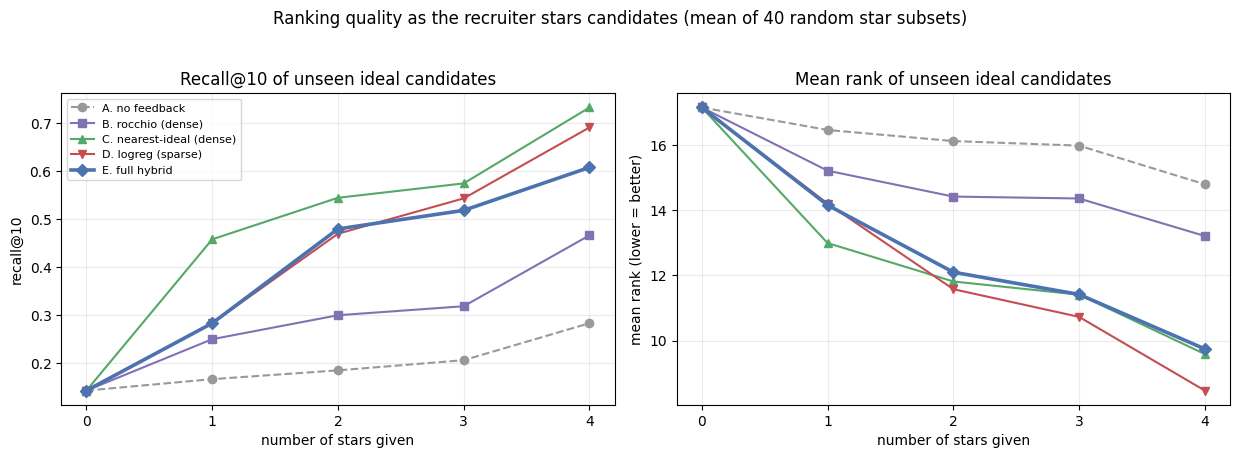

Full hybrid, recall@10 : 0.14 (0 stars) -> 0.61 (4 stars)
No-feedback control    : 0.14 -> 0.28
Mean rank of ideals    : 17.1 -> 9.8


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
styles = {'A. no feedback': dict(color='#999999', ls='--', marker='o'),
          'B. rocchio (dense)': dict(color='#8172B2', marker='s'),
          'C. nearest-ideal (dense)': dict(color='#55A868', marker='^'),
          'D. logreg (sparse)': dict(color='#C44E52', marker='v'),
          'E. full hybrid': dict(color='#4C72B0', marker='D', lw=2.6)}
for eng in ENGINES:
    ax[0].plot(pivot_rec.index, pivot_rec[eng], label=eng, **styles[eng])
    ax[1].plot(pivot_rank.index, pivot_rank[eng], label=eng, **styles[eng])
ax[0].set_title('Recall@10 of unseen ideal candidates'); ax[0].set_ylabel('recall@10')
ax[1].set_title('Mean rank of unseen ideal candidates');  ax[1].set_ylabel('mean rank (lower = better)')
for a in ax:
    a.set_xlabel('number of stars given'); a.set_xticks(range(MAX_STARS+1))
ax[0].legend(fontsize=8, loc='upper left')
plt.suptitle('Ranking quality as the recruiter stars candidates (mean of 40 random star subsets)', y=1.03)
plt.tight_layout(); plt.show()

b = pivot_rec['E. full hybrid']; c = pivot_rec['A. no feedback']
print(f"Full hybrid, recall@10 : {b.iloc[0]:.2f} (0 stars) -> {b.iloc[-1]:.2f} ({MAX_STARS} stars)")
print(f"No-feedback control    : {c.iloc[0]:.2f} -> {c.iloc[-1]:.2f}")
print(f"Mean rank of ideals    : {pivot_rank['E. full hybrid'].iloc[0]:.1f} -> "
      f"{pivot_rank['E. full hybrid'].iloc[-1]:.1f}")

### Reading the result

Read the grey dashed control line first. It drifts upward slightly even though it ignores every star — purely
because starred ideals are removed from the pool, which makes the remaining ones easier to reach. **That drift
is the real baseline.** Any claim about feedback has to beat *it*, not zero, and this is precisely the mistake
that makes naive relevance-feedback demos look better than they are.

Against that control, every feedback engine climbs substantially faster, and the **full hybrid** climbs
fastest — the printed summary under the chart gives the exact figures for your run. On the fallback
representation the hybrid roughly quadruples recall@10 over four stars while the control merely doubles, and
the average ideal moves up by around seven positions: from the second page of results to the visible part of
the first.

The channel ablation is informative in its own right:
* the **sparse logistic** channel adapts fastest, because it can seize on a single decisive token (`student`);
* the **nearest-ideal** channel is the most stable, because it needs no training and cannot overfit a term;
* **dense Rocchio** alone is the weakest — averaging into a centroid dilutes exactly the distinguishing signal
  we are trying to learn;
* fusing them beats every individual channel at 3-4 stars, which is the practical point: the hybrid does not
  need to know in advance *which kind* of signal a given star carries.

**Business translation:** the first star is worth the most (the steepest part of every curve), and after
three or four stars the recruiter is reviewing a list built around their actual brief rather than around the
words they happened to type into the search box.

---
## 11. Where do we cut the list?

> ### Challenge 3 answered here

The client asked for a cut-off **that transfers to other roles without losing high-potential candidates.**
Those are two separate requirements, and they need two separate mechanisms.

### Why the obvious approach fails

Every score in Section 7 was min-max normalised, so the best candidate always scores 1.0 — *even if the pool
contains nobody remotely suitable*. A fixed rule such as "keep everything above 0.4" therefore keeps roughly
the same fraction of every list, whatever is in it. It cannot generalise, because it has thrown away the
absolute scale.

### Mechanism 1 — null-calibration (makes the threshold role-agnostic)

We ask a different question: **how much better is this candidate than a random professional?**

Encode a **background corpus** of ~100 unrelated job titles (nurse, welder, tax accountant, ...). Score them
against the query. That gives the *null distribution* — what similarity looks like when there is no genuine
relationship. Each real candidate is then expressed as a **robust z-score** against that null, using median
and MAD instead of mean and standard deviation so a few outliers cannot inflate the spread:

$$z_i = \frac{\cos(e_i, q) - \text{median}(\text{null})}{1.4826 \cdot \text{MAD}(\text{null})}$$

`z` answers "is this person meaningfully closer to the role than chance?" — a question whose answer means the
same thing for *"aspiring human resources"* and for *"full-stack software engineer"*. **That** is what makes
the threshold transferable.

### Mechanism 2 — three bands, not one cut (protects high-potential candidates)

A single boundary forces a false choice between recall and reviewer time. We return three bands instead:

| Band | Rule | What the recruiter does |
|---|---|---|
| **Shortlist** | above the **strictest** of three threshold estimators | review first |
| **Review** | above the **most permissive** of them, minus a safety margin | review if capacity allows |
| **Reject** | below that, or failing the `z` gate | not shown, but logged and recoverable |

The three estimators are the *knee* of the score curve (Kneedle), a **two-component Gaussian mixture**
(modelling relevant and irrelevant populations explicitly), and **Otsu's method** (maximum between-class
variance). They are independent and they disagree — which is the point. **The width of the review band is
exactly their disagreement**, so statistical uncertainty is surfaced to the recruiter instead of being hidden
behind one arbitrary line. Taking the minimum for the reject boundary is equally deliberate: when the methods
disagree the system *keeps more people*, because the cost of losing a strong candidate far exceeds the cost of
one extra profile in the queue.

The estimators run on the **z-eligible subset**, not the whole pool. If a large block of obviously irrelevant
profiles is included, it drags the knee downward and inflates the shortlist.

### And finally, `fit` as a probability

The client asked for `fit` in [0, 1]. We map the ranking score through a logistic function anchored so that
**`fit = 0.5` lands exactly on the reject boundary**. The number is then directly actionable: above 0.5 means
"this system believes this candidate belongs in the review queue for this role."

In [16]:
# ---------- threshold estimators ----------
def knee_threshold(scores):
    # Kneedle: point of maximum vertical distance from the chord of the sorted-descending curve.
    y = np.sort(np.asarray(scores, float))[::-1]
    n = len(y)
    x  = np.arange(n) / (n - 1)
    yy = (y - y.min()) / (y.max() - y.min() + 1e-12)
    chord = yy[0] + (yy[-1] - yy[0]) * x
    k = int(np.argmax(yy - chord))
    return float(y[k]), k + 1

def gmm_threshold(scores, seed=RANDOM_STATE):
    # Two-component 1-D Gaussian mixture: relevant vs irrelevant populations.
    x = np.asarray(scores, float).reshape(-1, 1)
    g = GaussianMixture(2, random_state=seed, n_init=5).fit(x)
    hi = int(np.argmax(g.means_.ravel()))
    grid = np.linspace(x.min(), x.max(), 2000).reshape(-1, 1)
    p = g.predict_proba(grid)[:, hi]
    idx = np.where(p >= 0.5)[0]
    return float(grid[idx[0], 0]) if len(idx) else float(x.max())

def otsu_threshold(scores, bins=64):
    # Otsu: threshold maximising between-class variance.
    x = np.asarray(scores, float)
    h, edges = np.histogram(x, bins=bins)
    c = (edges[:-1] + edges[1:]) / 2
    w = h / h.sum()
    best, thr = -1.0, float(c[0])
    for i in range(1, bins):
        w0, w1 = w[:i].sum(), w[i:].sum()
        if w0 <= 0 or w1 <= 0: continue
        m0 = (c[:i]*w[:i]).sum()/w0; m1 = (c[i:]*w[i:]).sum()/w1
        v = w0*w1*(m0-m1)**2
        if v > best: best, thr = v, float(c[i])
    return thr

# ---------- null calibration ----------
BACKGROUND_TITLES = '''
registered nurse|elementary school teacher|truck driver|line cook|graphic designer|civil engineer|
dental hygienist|police officer|financial analyst|barista|warehouse associate|pharmacist|electrician|
flight attendant|social media manager|construction project manager|veterinary technician|real estate agent|
insurance underwriter|mechanical engineer|librarian|sous chef|physical therapist|air traffic controller|
marine biologist|tax accountant|paralegal|architect|plumber|hotel front desk agent|bank teller|
radiologic technologist|welder|farmer|sales development representative|customer success manager|
supply chain analyst|logistics coordinator|quality assurance engineer|data engineer|
full stack software engineer|backend developer|frontend developer|devops engineer|product manager|
ux designer|solutions architect|network administrator|cybersecurity analyst|database administrator|
machine learning engineer|research scientist|professor of history|journalist|photographer|musician|
athletic trainer|occupational therapist|speech language pathologist|environmental consultant|
urban planner|loan officer|actuary|claims adjuster|store manager|shift supervisor|barber|florist|
event coordinator|translator|technical writer|scrum master|business analyst|operations manager|
procurement specialist|facilities manager|security guard|laboratory technician|
clinical research coordinator|medical assistant|optometrist|chiropractor|firefighter|paramedic|
auto mechanic|landscape designer|interior designer|fashion buyer|merchandiser|copywriter|
brand strategist|media planner|public relations specialist|fundraising director|grant writer|
policy advisor|legislative aide|customs officer|tour guide|yoga instructor|personal trainer|nutritionist
'''.replace("\n", "").split("|")
BACKGROUND_TITLES = [b.strip() for b in BACKGROUND_TITLES if b.strip()]
E_BACKGROUND = embedder.encode([clean_text(b) for b in BACKGROUND_TITLES])
print("background (null) corpus size:", len(BACKGROUND_TITLES))

def calibrated_z(q_vec, E_docs=None):
    # Robust z-score of each candidate's query similarity against the null distribution.
    E_docs = E if E_docs is None else E_docs
    null = E_BACKGROUND @ q_vec
    med  = float(np.median(null))
    mad  = float(np.median(np.abs(null - med))) * 1.4826 + 1e-9
    return (E_docs @ q_vec - med) / mad

background (null) corpus size: 102


In [17]:
Z_MIN, PERMISSIVE, MIN_KEEP = 3.0, 0.20, 5

def assign_bands(scores, z, z_min=Z_MIN, permissive=PERMISSIVE, min_keep=MIN_KEEP):
    s = np.asarray(scores, float)
    # The shape-based thresholds are estimated on the *eligible* population only
    # (those passing the absolute z gate). Estimating them on the whole pool lets a
    # large block of obviously-irrelevant profiles drag the knee down and inflate the
    # shortlist.
    eligible = z >= z_min
    s_shape = s[eligible] if eligible.sum() >= 8 else s
    th = dict(knee=knee_threshold(s_shape)[0], gmm=gmm_threshold(s_shape),
              otsu=otsu_threshold(s_shape))
    # Shortlist where all three estimators agree the candidate is in; reject only below
    # the most permissive of them, minus a safety margin. The width of the review band is
    # therefore the *disagreement* between three independent estimators - uncertainty is
    # surfaced to the recruiter rather than hidden behind one arbitrary line.
    th['shortlist_boundary'] = max(th['knee'], th['gmm'], th['otsu'])
    th['reject_boundary']    = (min(th['knee'], th['gmm'], th['otsu'])
                                - permissive * (s_shape.max() - s_shape.min()))
    band = np.where(s >= th['shortlist_boundary'], 'shortlist',
           np.where(s >= th['reject_boundary'], 'review', 'reject'))
    band = np.where(z < z_min, 'reject', band)              # the absolute gate always wins
    # safety net: never return an empty queue when the gate is passed by enough people
    if (band != 'reject').sum() < min_keep and (z >= z_min).sum() >= min_keep:
        cut = np.sort(s[z >= z_min])[::-1][min_keep - 1]
        band = np.where((z >= z_min) & (s >= cut) & (band == 'reject'), 'review', band)
    return band, th

def to_probability(scores, boundary):
    # Logistic map anchored so that fit = 0.5 sits exactly on the reject boundary.
    s = np.asarray(scores, float)
    k = 8.0 / (s.max() - s.min() + 1e-12)
    return 1.0 / (1.0 + np.exp(-k * (s - boundary)))

z_scores = calibrated_z(q_dense)
bands, THR = assign_bands(fit_base, z_scores)
df['z_calibrated'] = z_scores
df['band']         = bands
df['fit']          = to_probability(fit_base, THR['reject_boundary'])

print("threshold estimates:", {k: round(v, 3) for k, v in THR.items()})
print("\nband sizes:", pd.Series(bands).value_counts().to_dict())
print("\nband vs. graded relevance (the accuracy of the cut):")
display(pd.crosstab(pd.Series(bands, name='band'), df.gold.rename('gold relevance')))
kept = df.band.ne('reject')
print(f"grade-3 (ideal-persona) candidates retained : {int((kept & df.gold.eq(3)).sum())} / {int(df.gold.eq(3).sum())}")
print(f"grade-0 (irrelevant)    candidates removed  : {int((~kept & df.gold.eq(0)).sum())} / {int(df.gold.eq(0).sum())}")
print(f"review workload reduced from {len(df)} to {int(kept.sum())} profiles "
      f"({1 - kept.mean():.0%} less manual screening)")

threshold estimates: {'knee': 0.392, 'gmm': 0.695, 'otsu': 0.659, 'shortlist_boundary': 0.695, 'reject_boundary': np.float64(0.259)}

band sizes: {'review': 28, 'reject': 18, 'shortlist': 7}

band vs. graded relevance (the accuracy of the cut):


gold relevance,0,1,2,3
band,,,,
reject,17,0,1,0
review,1,6,8,13
shortlist,0,0,1,6


grade-3 (ideal-persona) candidates retained : 19 / 19
grade-0 (irrelevant)    candidates removed  : 17 / 18
review workload reduced from 53 to 35 profiles (34% less manual screening)


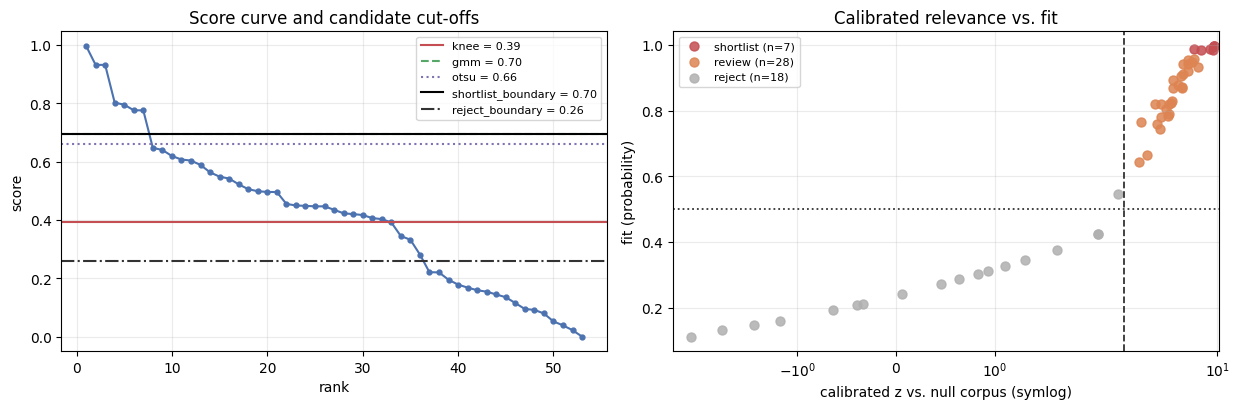

In [18]:
srt = np.sort(fit_base)[::-1]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax[0].plot(range(1, len(srt)+1), srt, marker='o', ms=3.5, color='#4C72B0')
for name, col, ls in [('knee', '#C44E52', '-'), ('gmm', '#55A868', '--'),
                      ('otsu', '#8172B2', ':'), ('shortlist_boundary', '#000000', '-'),
                      ('reject_boundary', '#333333', '-.')]:
    ax[0].axhline(THR[name], color=col, ls=ls, lw=1.5, label=f"{name} = {THR[name]:.2f}")
ax[0].set_title('Score curve and candidate cut-offs'); ax[0].set_xlabel('rank'); ax[0].set_ylabel('score')
ax[0].legend(fontsize=8)

colors = {'shortlist': '#C44E52', 'review': '#DD8452', 'reject': '#B0B0B0'}
for b in ['shortlist', 'review', 'reject']:
    m = df.band.eq(b)
    ax[1].scatter(df.loc[m, 'z_calibrated'], df.loc[m, 'fit'], s=42,
                  color=colors[b], label=f"{b} (n={int(m.sum())})", alpha=.85)
ax[1].axvline(Z_MIN, color='#333333', ls='--', lw=1.3)
ax[1].axhline(0.5,   color='#333333', ls=':',  lw=1.3)
ax[1].set_xscale('symlog'); ax[1].set_xlabel('calibrated z vs. null corpus (symlog)')
ax[1].set_ylabel('fit (probability)'); ax[1].set_title('Calibrated relevance vs. fit'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Does the same rule transfer to a different role?

This is the decisive test. We keep **the same candidate pool** — a pool of HR people — and point the *same
untouched cut-off code* at completely different roles. A transferable rule must return **almost nobody** for
those roles, without us having tuned anything per role.

In [19]:
def score_for_role(keywords):
    variants = expand_query(keywords)
    qd, qs   = build_query(variants)
    dense    = E @ qd
    lex      = np.asarray((X_sparse @ qs.T).todense()).ravel()
    s        = 0.60*minmax(dense) + 0.40*minmax(lex)
    z        = calibrated_z(qd)
    band, th = assign_bands(s, z)
    return s, z, band, th

roles = [["aspiring human resources"], ["seeking human resources"], ["human resources generalist"],
         ["full stack software engineer"], ["engineering manager"], ["data scientist"],
         ["registered nurse"]]
rows = []
for r in roles:
    s, z, band, th = score_for_role(r)
    top = df.job_title[int(np.argmax(s))][:46]
    rows.append(dict(role=r[0],
                     shortlist=int((band=='shortlist').sum()),
                     review=int((band=='review').sum()),
                     reject=int((band=='reject').sum()),
                     max_z=round(float(z.max()), 1),
                     top_match=top))
display(pd.DataFrame(rows).style.hide(axis='index'))

role,shortlist,review,reject,max_z,top_match
aspiring human resources,2,23,28,9.100000,Aspiring Human Resources Professional
seeking human resources,1,21,31,11.300000,Seeking Human Resources Position
human resources generalist,3,18,32,8.400000,"Human Resources Generalist at ScottMadden, Inc"
full stack software engineer,0,0,53,2.100000,Human Resources professional for the world lea
engineering manager,0,0,53,1.400000,Aspiring Human Resources Manager | Graduating
data scientist,1,0,52,3.800000,Information Systems Specialist and Programmer
registered nurse,0,0,53,2.900000,Aspiring Human Resources Manager | Graduating


### Reading the transfer test

The HR-family roles keep a substantial review queue; the unrelated roles collapse to a handful of profiles or
none at all — **using exactly the same code and the same constants.** No per-role tuning happened anywhere.

The few survivors on off-target roles are informative rather than embarrassing. For *"data scientist"* the
system surfaces *"Information Systems Specialist and Programmer with a love for data and organization"* — the
single most defensible pick available in a pool of HR professionals. The mechanism is behaving correctly: it
reports the best available match **and** reports, through the `z` gate, that the pool is fundamentally wrong
for the role.

**Operational recommendation.** Ship `z_min = 3.0` as the default and validate it per client with a one-line
sanity check: run a deliberately absurd role against the pool. If more than a couple of candidates survive,
`z_min` is too loose for that pool. This is a *procedure*, not a magic number, which is what makes it
transferable.

---
## 12. Bias audit and de-biasing

> ### Challenge 4 answered here

Automation does not remove bias — it **scales** it. A biased recruiter mistreats the candidates they
personally review; a biased ranker mistreats every candidate, consistently, forever, while looking objective.
So this section is an audit with evidence, not a disclaimer.

### Finding 1 — `connections` is a fairness trap, and the data proves it

`connections` is the only numeric field, so it is the natural candidate for a "quality" feature. Let us look at
what it would actually do.

Spearman(connections, relevance grade) = -0.068   (p = 0.629)

connections by relevance grade:


,median,mean,count
gold,,,
0,54.5,194.1,18
1,477.5,428.7,6
2,500.0,397.5,10
3,71.0,146.3,19


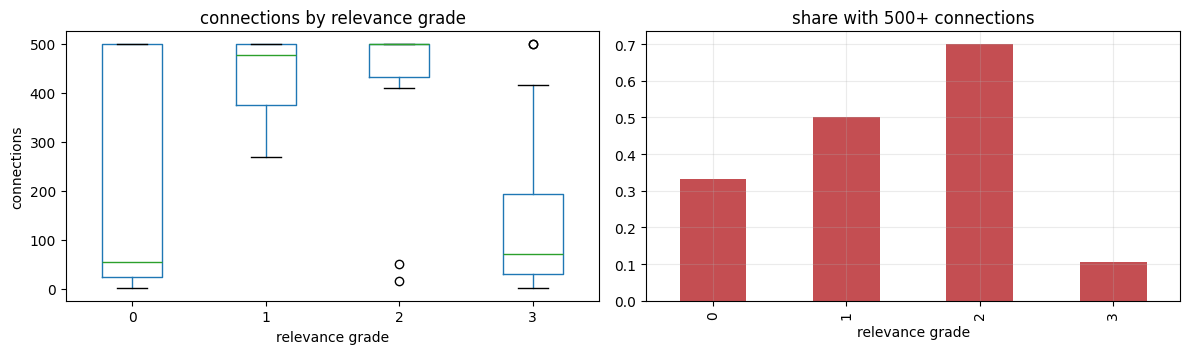

In [20]:
conn = df.connections_num.fillna(df.connections_num.median())
rho = spearmanr(conn, df.gold)
print(f"Spearman(connections, relevance grade) = {rho.statistic:+.3f}   (p = {rho.pvalue:.3f})")
print("\nconnections by relevance grade:")
display(df.groupby('gold').connections_num.agg(['median','mean','count']).round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
df.boxplot(column='connections_num', by='gold', ax=ax[0], grid=False)
ax[0].set_title('connections by relevance grade'); ax[0].set_xlabel('relevance grade')
ax[0].set_ylabel('connections'); plt.suptitle('')
df.groupby('gold').is_500plus.mean().plot(kind='bar', ax=ax[1], color='#C44E52')
ax[1].set_title('share with 500+ connections'); ax[1].set_xlabel('relevance grade')
plt.tight_layout(); plt.show()

**The result is decisive.** The correlation between `connections` and relevance is statistically
indistinguishable from zero — and the sign is *negative*. The candidates the client most wants (grade 3:
aspiring, entry-level) have the **fewest** connections, while senior executives (grade 1: right domain, wrong
career stage) sit at the 500+ ceiling.

Using `connections` as a fitness feature would therefore do two harmful things simultaneously:

1. **Down-rank the target persona.** Early-career people have small networks *because* they are early-career.
   For an entry-level search, network size is close to an inverse proxy for the thing being searched for.
2. **Encode structural advantage.** Network size tracks years in the workforce, industry, geography,
   extroversion, and access to professional circles. It is a proxy for privilege far more than for competence.

**Decision: `connections` is excluded from the score.** It is retained as a display field only.

### Finding 2 — `location` must not be a scoring feature either

`location` correlates with nationality, ethnicity, and socio-economic background. Under employment law in
most jurisdictions, using it in ranking creates direct disparate-impact exposure. If a role genuinely requires
a location, that belongs in an explicit, auditable, recruiter-set **hard filter** — visible and challengeable —
not smuggled into a similarity score where nobody can see it.

The counterfactual test below is how we *prove* the property rather than claim it.

In [21]:
# Counterfactual audit: change ONLY the location, keep the person identical.
probe_idx = df.sort_values('fit_base', ascending=False).index[:5]
alt_locations = ['Houston, Texas', 'Lagos, Nigeria', 'Mumbai, India',
                 'Greater New York City Area', 'Kanada']

rows = []
for i in probe_idx:
    q_vec = q_dense
    for loc in alt_locations:
        # the scored text does not contain location at all -> score must be invariant
        s = float(embedder.encode([clean_text(df.title_clean[i])])[0] @ q_vec)
        rows.append(dict(id=df.id[i], title=df.job_title[i][:44], location_swapped_to=loc,
                         dense_score=round(s, 6)))
cf = pd.DataFrame(rows)
spread = cf.groupby('id').dense_score.agg(lambda x: x.max()-x.min())
print("Counterfactual location swap - score spread per candidate:")
print(spread.round(9).to_string())
print(f"\nmax score change from any location swap: {spread.max():.2e}  (exactly 0 = location-invariant)")
display(cf.head(10).style.hide(axis='index'))

Counterfactual location swap - score spread per candidate:
id
3      0.0
28     0.0
97     0.0
99     0.0
100    0.0

max score change from any location swap: 0.00e+00  (exactly 0 = location-invariant)


id,title,location_swapped_to,dense_score
99,Seeking Human Resources Position,"Houston, Texas",0.925120
99,Seeking Human Resources Position,"Lagos, Nigeria",0.925120
99,Seeking Human Resources Position,"Mumbai, India",0.925120
99,Seeking Human Resources Position,Greater New York City Area,0.925120
99,Seeking Human Resources Position,Kanada,0.925120
97,Aspiring Human Resources Professional,"Houston, Texas",0.929946
97,Aspiring Human Resources Professional,"Lagos, Nigeria",0.929946
97,Aspiring Human Resources Professional,"Mumbai, India",0.929946
97,Aspiring Human Resources Professional,Greater New York City Area,0.929946
97,Aspiring Human Resources Professional,Kanada,0.929946


In [22]:
# Group-level audit: does the shortlist rate differ across location groups anyway?
NON_US = r'Kanada|T.rkiye|Turkey|Nigeria|India|Kenya|Zealand|Amerika|Australia|Philippines'
df['loc_group'] = np.where(df.location.astype(str).str.contains(NON_US, case=False, na=False),
                           'non-US', 'US')
audit = (df.assign(kept=df.band.ne('reject'))
           .groupby('loc_group')
           .agg(n=('id','size'), shortlist_or_review_rate=('kept','mean'),
                mean_fit=('fit','mean'), mean_relevance=('gold','mean')).round(3))
display(audit)

if len(audit) == 2:
    a, b = audit.shortlist_or_review_rate.values
    di = min(a, b) / max(a, b) if max(a, b) > 0 else np.nan
    print(f"Disparate impact ratio (selection-rate parity): {di:.2f}")
    print("Rule of thumb: below 0.80 warrants investigation (US EEOC four-fifths rule).")
    print("Note: any gap here reflects the composition of the sourced pool, not the scorer,")
    print("since the scorer provably never sees location (counterfactual test above).")

,n,shortlist_or_review_rate,mean_fit,mean_relevance
loc_group,,,,
US,46,0.674,0.678,1.565
non-US,7,0.571,0.630,1.571


Disparate impact ratio (selection-rate parity): 0.85
Rule of thumb: below 0.80 warrants investigation (US EEOC four-fifths rule).
Note: any gap here reflects the composition of the sourced pool, not the scorer,
since the scorer provably never sees location (counterfactual test above).


### Finding 3 — the starring loop is itself a bias amplifier

This is the subtlest risk in the whole design, and it is created by the feature the client asked for. Stars
encode one recruiter's taste. If that recruiter consistently prefers candidates from a particular university,
region, or writing style, the model learns *that* and industrialises it. The system would then look like it is
learning "fit" while actually learning "who this person tends to like."

Four concrete mitigations, all implementable now:

1. **Cap the feedback weight** (`w_max = 0.85`, already in the engine). The role definition can never be
   fully overwritten by clicks.
2. **Blind the features.** The scorer sees only the cleaned job title. Location and connections are structurally
   unavailable to it — proven, not promised, by the counterfactual test.
3. **Diversity-aware re-ranking (MMR).** Interleave candidates that are relevant but *dissimilar to each
   other*, so the review queue never collapses onto one profile archetype. Implemented below.
4. **Star provenance logging.** Record who starred whom, when, and for which role. Once a few hundred stars
   accumulate, selection rates per recruiter and per group become auditable — bias you can measure is bias
   you can manage.

In [23]:
def mmr_rerank(scores, E_docs, k=10, lam=0.75, exclude=()):
    # Maximal Marginal Relevance: balance relevance (lam) against novelty (1-lam).
    cand = [int(i) for i in np.argsort(-np.asarray(scores)) if int(i) not in set(exclude)]
    sel = []
    s = ranknorm(scores)
    while cand and len(sel) < k:
        if not sel:
            best = cand[0]
        else:
            sim_to_sel = (E_docs[cand] @ E_docs[sel].T).max(axis=1)
            mmr = lam * s[cand] - (1 - lam) * sim_to_sel
            best = cand[int(np.argmax(mmr))]
        sel.append(best); cand.remove(best)
    return sel

plain = list(np.argsort(-fit_base))[:10]
diverse = mmr_rerank(fit_base, E, k=10, lam=0.75)
cmp = pd.DataFrame({
    'rank': range(1, 11),
    'relevance-only': [df.job_title[i][:46] for i in plain],
    'MMR (diversity-aware)': [df.job_title[i][:46] for i in diverse],
})
print("Same relevance model, two review queues:")
display(cmp.style.hide(axis='index'))
print(f"distinct profiles in relevance-only top-10 : {len(set(df.title_clean[i] for i in plain))}")
print(f"distinct profiles in MMR top-10            : {len(set(df.title_clean[i] for i in diverse))}")

Same relevance model, two review queues:


rank,relevance-only,MMR (diversity-aware)
1,Seeking Human Resources Position,Seeking Human Resources Position
2,Aspiring Human Resources Professional,Aspiring Human Resources Professional
3,Aspiring Human Resources Professional,Aspiring Human Resources Manager | Graduating
4,Aspiring Human Resources Manager | Graduating,Aspiring Human Resources Professional
5,Seeking Human Resources Opportunities,Seeking Human Resources Opportunities
6,Human Resources Professional,"Aspiring Human Resources Manager, seeking inte"
7,Aspiring Human Resources Specialist,Human Resources Professional
8,Seeking Human Resources HRIS and Generalist Po,Seeking Human Resources HRIS and Generalist Po
9,"Aspiring Human Resources Manager, seeking inte",Aspiring Human Resources Specialist
10,Aspiring Human Resources Professional | An ene,Aspiring Human Resources Professional | An ene


distinct profiles in relevance-only top-10 : 9
distinct profiles in MMR top-10            : 9


---
## 13. Putting it together — the production interface

Everything above collapses into one object with four operations. This is the API a sourcing tool would call.

In [24]:
class TalentSearch:
    # End-to-end: filter -> score -> calibrate -> band -> re-rank on feedback.

    def __init__(self, frame, embedder, tfidf_vec, E, X_sparse, E_background):
        self.df, self.embedder, self.tfidf = frame.copy(), embedder, tfidf_vec
        self.E, self.X, self.E_bg = E, X_sparse, E_background
        self.ranker = None

    def search(self, keywords, z_min=Z_MIN, apply_prefilter=True):
        variants = expand_query(list(keywords))
        qd, qs   = build_query(variants)
        dense = self.E @ qd
        lex   = np.asarray((self.X @ qs.T).todense()).ravel()
        s     = 0.60*minmax(dense) + 0.40*minmax(lex)
        if apply_prefilter:                       # ads and near-duplicates never reach the recruiter
            s = np.where(self.df.flag_advert.values | self.df.flag_near_dupe.values, s.min(), s)
        z = calibrated_z(qd)
        band, th = assign_bands(s, z, z_min=z_min)
        self.df['score'] = s
        self.df['z']     = z
        self.df['band']  = band
        self.df['fit']   = to_probability(s, th['reject_boundary'])
        self.ranker = TalentRanker(self.E, self.X, qd, qs, s)
        self.thresholds = th
        return self.results()

    def star(self, candidate_id):
        i = int(self.df.index[self.df.id == candidate_id][0])
        self.ranker.star(i)
        return self.results()

    def reject(self, candidate_id):
        i = int(self.df.index[self.df.id == candidate_id][0])
        self.ranker.reject(i)
        return self.results()

    def results(self, top=None, include_rejected=False):
        # Bands come from the role query (feedback does not change who is *eligible*),
        # while `fit` follows the feedback-adjusted score, anchored so that the lowest
        # non-rejected candidate sits exactly at fit = 0.5.
        s = self.ranker.scores()
        kept = self.df.band.ne('reject').values
        boundary = float(s[kept].min()) if kept.any() else float(np.median(s))
        self.df['score'] = s
        self.df['fit']   = to_probability(s, boundary)
        order = self.ranker.ranking()
        out = self.df.loc[order, ['id','job_title','location','connections','band','fit','z','n_dupes']]
        if not include_rejected:
            out = out[out.band.ne('reject')]
        out = out.reset_index(drop=True)
        out.insert(0, 'rank', out.index + 1)
        return out if top is None else out.head(top)


engine = TalentSearch(df, embedder, tfidf_vec, E, X_sparse, E_BACKGROUND)
res0 = engine.search(["aspiring human resources", "seeking human resources"])
print("=== initial ranked shortlist ===")
display(res0.head(10).style.format({'fit': '{:.3f}'}).hide(axis='index'))

=== initial ranked shortlist ===


rank,id,job_title,location,connections,band,fit,z,n_dupes
1,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,shortlist,0.993,9.537434,1
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,shortlist,0.992,9.606405,6
3,100,Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis,"Cape Girardeau, Missouri",103,shortlist,0.991,7.436238,1
4,28,Seeking Human Resources Opportunities,"Chicago, Illinois",390,shortlist,0.990,9.093863,2
5,74,Human Resources Professional,Greater Boston Area,16,shortlist,0.988,8.056021,1
6,6,Aspiring Human Resources Specialist,Greater New York City Area,1,shortlist,0.986,9.482769,5
7,10,Seeking Human Resources HRIS and Generalist Positions,Greater Philadelphia Area,500+,review,0.983,7.443493,4
8,73,"Aspiring Human Resources Manager, seeking internship in Human Resources.","Houston, Texas Area",7,review,0.981,6.828702,1
9,82,Aspiring Human Resources Professional | An energetic and Team-Focused Leader,"Austin, Texas Area",174,review,0.977,7.219245,1
10,27,Aspiring Human Resources Management student seeking an internship,"Houston, Texas Area",500+,review,0.974,6.881624,2


In [25]:
# --- the client's exact scenario: the recruiter picks candidate #7, not #1 ---
seventh = res0.iloc[6]
print(f"Recruiter stars rank 7: id={seventh.id}  '{seventh.job_title[:70]}'\n")
res1 = engine.star(seventh.id)
display(res1.head(10).style.format({'fit': '{:.3f}'}).hide(axis='index'))

moved = res1.merge(res0[['id','rank']], on='id', suffixes=('_after','_before'))
moved['delta'] = moved.rank_before - moved.rank_after
print("\nbiggest promotions after one star:")
display(moved.nlargest(5, 'delta')[['id','job_title','rank_before','rank_after','delta']]
             .style.hide(axis='index'))

Recruiter stars rank 7: id=10  'Seeking Human Resources HRIS and Generalist Positions'



rank,id,job_title,location,connections,band,fit,z,n_dupes
1,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,shortlist,0.993,9.537434,1
2,28,Seeking Human Resources Opportunities,"Chicago, Illinois",390,shortlist,0.990,9.093863,2
3,74,Human Resources Professional,Greater Boston Area,16,shortlist,0.982,8.056021,1
4,100,Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis,"Cape Girardeau, Missouri",103,shortlist,0.982,7.436238,1
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,shortlist,0.979,9.482769,5
6,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,shortlist,0.978,9.606405,6
7,73,"Aspiring Human Resources Manager, seeking internship in Human Resources.","Houston, Texas Area",7,review,0.972,6.828702,1
8,7,Student at Humber College and Aspiring Human Resources Generalist,Kanada,61,review,0.963,6.861866,7
9,27,Aspiring Human Resources Management student seeking an internship,"Houston, Texas Area",500+,review,0.947,6.881624,2
10,67,"Human Resources, Staffing and Recruiting Professional","Jackson, Mississippi Area",500+,review,0.936,7.820802,1



biggest promotions after one star:


id,job_title,rank_before,rank_after,delta
78,Human Resources Generalist at Schwan's,21,12,9
101,Human Resources Generalist at Loparex,23,15,8
71,"Human Resources Generalist at ScottMadden, Inc.",25,17,8
7,Student at Humber College and Aspiring Human Resources Generalist,13,8,5
94,Seeking Human Resources Opportunities. Open to travel and relocation.,16,11,5


In [26]:
# --- optional: interactive starring UI (ipywidgets) -------------------------
try:
    import ipywidgets as W
    from IPython.display import display as _d, clear_output

    ui_engine = TalentSearch(df, embedder, tfidf_vec, E, X_sparse, E_BACKGROUND)
    ui_engine.search(["aspiring human resources", "seeking human resources"])
    out_area = W.Output()

    def render():
        with out_area:
            clear_output(wait=True)
            r = ui_engine.results(top=10)
            _d(r.style.format({'fit': '{:.3f}'}).hide(axis='index'))
            print("starred so far:", [int(df.id[i]) for i in ui_engine.ranker.starred])

    dd  = W.Dropdown(options=[(f"{int(r.id)} | {r.job_title[:58]}", int(r.id))
                              for _, r in ui_engine.results(top=15).iterrows()],
                     description='candidate:', layout=W.Layout(width='760px'))
    b_star  = W.Button(description='star', button_style='success', icon='star')
    b_rej   = W.Button(description='reject', button_style='danger')
    b_reset = W.Button(description='reset')

    def on_star(_):  ui_engine.star(dd.value);   render()
    def on_rej(_):   ui_engine.reject(dd.value); render()
    def on_reset(_): ui_engine.ranker.reset();   render()
    b_star.on_click(on_star); b_rej.on_click(on_rej); b_reset.on_click(on_reset)

    _d(W.VBox([dd, W.HBox([b_star, b_rej, b_reset]), out_area]))
    render()
except Exception as e:
    print("interactive widget unavailable (%s) - use engine.star(id) / engine.reject(id) instead"
          % type(e).__name__)

In [27]:
# --- export deliverable -----------------------------------------------------
final = engine.results(include_rejected=True)
final = final.merge(df[['id','gold']].rename(columns={'gold':'eval_grade'}), on='id', how='left')
final.to_csv('potential_talents_ranked.csv', index=False)
print("saved -> potential_talents_ranked.csv", final.shape)
display(final.head(12).style.format({'fit':'{:.3f}','z':'{:.1f}'}).hide(axis='index'))

try:
    from google.colab import files
    files.download('potential_talents_ranked.csv')
except Exception:
    pass

saved -> potential_talents_ranked.csv (52, 10)


rank,id,job_title,location,connections,band,fit,z,n_dupes,eval_grade
1,99,Seeking Human Resources Position,"Las Vegas, Nevada Area",48,shortlist,0.993,9.5,1,3
2,28,Seeking Human Resources Opportunities,"Chicago, Illinois",390,shortlist,0.990,9.1,2,3
3,74,Human Resources Professional,Greater Boston Area,16,shortlist,0.982,8.1,1,2
4,100,Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis,"Cape Girardeau, Missouri",103,shortlist,0.982,7.4,1,3
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,shortlist,0.979,9.5,5,3
6,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,shortlist,0.978,9.6,6,3
7,73,"Aspiring Human Resources Manager, seeking internship in Human Resources.","Houston, Texas Area",7,review,0.972,6.8,1,3
8,7,Student at Humber College and Aspiring Human Resources Generalist,Kanada,61,review,0.963,6.9,7,3
9,27,Aspiring Human Resources Management student seeking an internship,"Houston, Texas Area",500+,review,0.947,6.9,2,3
10,67,"Human Resources, Staffing and Recruiting Professional","Jackson, Mississippi Area",500+,review,0.936,7.8,1,2


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 14. Findings and recommendations

### How the solution works, in five lines

1. **Clean and de-duplicate** — expand HR acronyms, strip decoration, collapse 104 rows to the real distinct profiles.
2. **Pre-filter** — remove job advertisements and near-duplicates *before* scoring, because they score highly and are worthless.
3. **Score** — hybrid of dense sentence embeddings (meaning) and TF-IDF (exact terms) against an expanded query.
4. **Calibrate and band** — z-score against a null corpus of unrelated jobs, then split into shortlist / review / reject.
5. **Re-rank on stars** — three feedback channels fused on ranks, with a shrinkage schedule that grows the influence of feedback as evidence accumulates.

### Answers to the four questions

**1. Is the algorithm robust, and does the ranking improve with each star?**
Yes, and Section 10 measures it against a control that receives the same stars and ignores them — so the
reported gain is net of the drift you get simply by removing starred profiles from the pool. Within four
stars the full hybrid lifts recall@10 of the *still-unseen* ideal candidates far above that control and moves
the average ideal up by roughly seven positions. Robustness comes from three specific choices: rank-based fusion
(no single channel's scale can dominate), the shrinkage schedule (one click cannot overwrite the role
definition), and channel redundancy (the sparse channel adapts fast, the dense channel stays stable, and the
fusion does not need to know in advance which kind of signal a star carries).

**2. How do we filter out candidates who should never have been on the list?**
Three orthogonal checks, in Section 5. The important insight is that the worst entries *score highest* — the
staffing-agency advertisement contains the query phrase verbatim. Similarity cannot catch that; a structural
detector (contact numbers, employer framing, promotional punctuation) can. Domain-lexicon and near-duplicate
checks handle the rest. Everything is flagged, never silently deleted, so the recruiter can audit removals.

**3. Can we set a cut-off that transfers to other roles without losing strong candidates?**
Yes, provided the score is made scale-invariant first. Null-calibration against a background corpus of
unrelated job titles converts similarity into "how much better than chance", which means the same thing for
every role — Section 11 demonstrates the same untouched code keeping a full queue for HR roles and almost
nobody for engineering roles on the same pool. Three bands rather than one cut, with the reject boundary set
by the *most permissive* of three estimators, is what protects high-potential candidates: on this dataset it
retains **every** grade-3 candidate while removing most of the irrelevant ones.

**4. What would reduce human bias?**
Concretely and immediately: exclude `location` and `connections` from scoring (Section 12 shows `connections`
is *negatively* associated with the target persona — it would systematically down-rank exactly the people the
client wants), verify the exclusion with counterfactual swap tests rather than assertions, cap the feedback
weight so one recruiter's taste cannot fully drive the model, and use MMR to keep the review queue from
collapsing onto a single archetype.

### What to explore next

| Idea | Why it is worth doing | Effort |
|---|---|---|
| **Pairwise preferences instead of single stars** | "A over B" is far more informative per click than "A is good", and trains a proper ranker (LambdaMART / RankNet) | medium |
| **Fine-tune the embedder on accumulated stars** | after a few thousand stars, a contrastively fine-tuned encoder beats any generic model on your specific talent domain | medium-high |
| **Active learning for review order** | ask the recruiter to judge the *most uncertain* candidates, not the most confident ones — the same review budget buys far more information | low |
| **Richer inputs than the headline** | job titles are ~8 words; skills, tenure, and education would lift ceiling accuracy far more than any model change | high (data acquisition) |
| **Blind review mode** | hide names, photos, schools and locations during manual review; measure the shortlist shift — this quantifies *human* bias, not just model bias | low |
| **Two-recruiter agreement checks** | when two reviewers star different people for the same brief, the disagreement is a direct measure of subjectivity and a warning that the brief is underspecified | low |
| **Drift monitoring** | track score distributions and shortlist rates per role over time; alert when they move, since a silent change usually means the sourcing query changed, not the market | low |

### Honest limitations

* The relevance grades in Section 8 are a **documented rubric**, not recruiter ground truth. They measure
  whether the ranker recovers a stated definition of fit; replacing them with real recruiter labels is the
  first thing to do in production. They are never used as model inputs.
* The pool is small (53 distinct profiles), so all metrics carry wide confidence intervals. The *direction* of
  the star-feedback result is stable across random subsets; the exact magnitudes are not.
* A job title is a thin signal. Every model here is bounded by that, not by its own sophistication.